Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [1]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [ ]:
# Main code data processing
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\Data_Dpluspp7TeV_pT_2_3.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\FD_Dpluspp7TeV_pT_2_3 (1).root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

FD_df = pd.DataFrame(training_data_FD)
kbg_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([FD_df,kbg_df])

inv_mass = full_data["inv_mass"].values


In [4]:
print(len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))

#ratio background signal

810.3201663201663


In [5]:


#leave out inv_mass and pt
features = [c for c in full_data.columns 
            if c not in ["inv_mass", "pt_cand", "species"]]

x_data = full_data[features]
y_data = full_data['species']
print(set(y_data))

# stratify to ensure: fraction signal / background in train is approx. fraction signal / background in test
# if for example x_test[10] is selected, then : y_test[10] the label, and m_test[10] the invariant mass of event
x_train_full, x_test, y_train_full, y_test, m_train, m_test = train_test_split(
    x_data,
    y_data,
    inv_mass,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)


print(np.unique(y_train_full, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.

pos_class_weight = (len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))




{0.0, 1.0}
(array([0., 1.]), array([3741734,    4618]))


In [6]:
train_x, val_x, train_y, val_y, m_train, m_val = train_test_split(x_train_full, y_train_full, m_train, test_size=0.2, random_state=42, stratify=y_train_full)
dtrain = xgb.DMatrix(train_x, label=train_y)
dval = xgb.DMatrix(val_x, label=val_y)




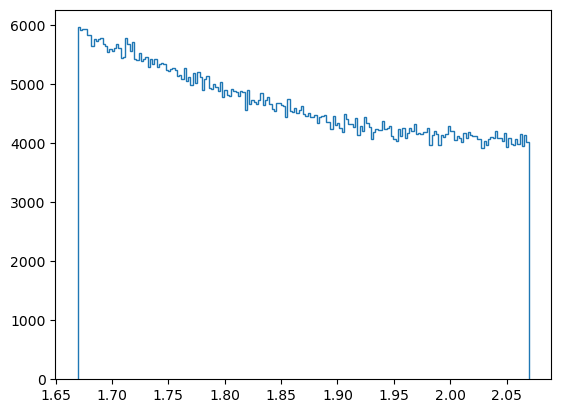

In [7]:
plt.hist(m_test[y_test==0], bins=200, histtype="step", label="Bkg (no cut)")
plt.show()

In [ ]:
import optuna
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import average_precision_score


from optuna.integration import XGBoostPruningCallback
import xgboost as xgb

# Define an objective function. This will find how good the model is performing, based on different hyperparameters.
# Using this function optuna will sample the hyperparameterspace to find the best hyperparameters for training.

#Fixed validation set is crucial, so: splitting data outside the loop.



def objective(trial):

   
    params = {
        "verbosity": 0,
       
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),

        'min_child_weight': trial.suggest_int('min_child_weight', 5, 40),
        # scale_pos_weight tune (not reccomended):
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", (pos_class_weight*0.9), (pos_class_weight*1.1))
        

        "scale_pos_weight": pos_class_weight,  # fixed class weight
        "reg_alpha": trial.suggest_float("reg_alpha", 1.0, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 50.0, 150.0, log=True),
    
       # "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.01, 1.0, log=True),

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True), #09
        "max_depth": trial.suggest_int("max_depth", 2, 6), 
        "subsample": trial.suggest_float("subsample", 0.3, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 0.9),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "max_delta_step": 1,
        "random_state": 42
    }
    num_boost_round = 1000 
    #params.update(base_params)
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-aucpr")
    bst = xgb.train(params, dtrain=dtrain, early_stopping_rounds=30, num_boost_round=num_boost_round, evals=[(dval, "validation")], callbacks=[pruning_callback])
    trial.set_user_attr('best_iteration', bst.best_iteration)

    scores = bst.predict(dval)

    
    y_true = val_y

    auc_val = average_precision_score(y_true, scores)


    trial.set_user_attr("val_aucpr", auc_val)


    return auc_val




if __name__ == "__main__":
    study = optuna.create_study(
        pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=120), direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=60)
    print("Best trial:")
    print(study.best_trial)



[I 2026-01-23 16:49:46,779] A new study created in memory with name: no-name-6c854d1d-7a80-489e-b53a-387d405d5db6


[0]	validation-aucpr:0.01004
[1]	validation-aucpr:0.03039
[2]	validation-aucpr:0.03046
[3]	validation-aucpr:0.03080
[4]	validation-aucpr:0.03075
[5]	validation-aucpr:0.05708
[6]	validation-aucpr:0.05704
[7]	validation-aucpr:0.05958
[8]	validation-aucpr:0.06038
[9]	validation-aucpr:0.06027
[10]	validation-aucpr:0.06894
[11]	validation-aucpr:0.06884
[12]	validation-aucpr:0.06874
[13]	validation-aucpr:0.06868
[14]	validation-aucpr:0.06899
[15]	validation-aucpr:0.06894
[16]	validation-aucpr:0.06922
[17]	validation-aucpr:0.06926
[18]	validation-aucpr:0.06927
[19]	validation-aucpr:0.06946
[20]	validation-aucpr:0.07677
[21]	validation-aucpr:0.07702
[22]	validation-aucpr:0.07712
[23]	validation-aucpr:0.07710
[24]	validation-aucpr:0.07707
[25]	validation-aucpr:0.07704
[26]	validation-aucpr:0.07697
[27]	validation-aucpr:0.07700
[28]	validation-aucpr:0.07696
[29]	validation-aucpr:0.07692
[30]	validation-aucpr:0.07692
[31]	validation-aucpr:0.07705
[32]	validation-aucpr:0.07707
[33]	validation-aucp

[I 2026-01-23 16:56:14,983] Trial 0 finished with value: 0.32624886151659377 and parameters: {'n_estimators': 874, 'min_child_weight': 39, 'reg_alpha': 8.960785365368121, 'reg_lambda': 96.5167504314665, 'gamma': 0.020513382630874502, 'learning_rate': 0.015957084694148364, 'max_depth': 2, 'subsample': 0.8197056874649611, 'colsample_bytree': 0.5808920093945671}. Best is trial 0 with value: 0.32624886151659377.


[0]	validation-aucpr:0.00982
[1]	validation-aucpr:0.02937
[2]	validation-aucpr:0.03030
[3]	validation-aucpr:0.03029
[4]	validation-aucpr:0.03030
[5]	validation-aucpr:0.05777
[6]	validation-aucpr:0.05762
[7]	validation-aucpr:0.07331
[8]	validation-aucpr:0.07360
[9]	validation-aucpr:0.07350
[10]	validation-aucpr:0.08301
[11]	validation-aucpr:0.08293
[12]	validation-aucpr:0.08779
[13]	validation-aucpr:0.08753
[14]	validation-aucpr:0.08813
[15]	validation-aucpr:0.08813
[16]	validation-aucpr:0.08855
[17]	validation-aucpr:0.08858
[18]	validation-aucpr:0.08855
[19]	validation-aucpr:0.08818
[20]	validation-aucpr:0.08816
[21]	validation-aucpr:0.08812
[22]	validation-aucpr:0.08842
[23]	validation-aucpr:0.08839
[24]	validation-aucpr:0.08832
[25]	validation-aucpr:0.08996
[26]	validation-aucpr:0.08994
[27]	validation-aucpr:0.08989
[28]	validation-aucpr:0.08986
[29]	validation-aucpr:0.08984
[30]	validation-aucpr:0.09116
[31]	validation-aucpr:0.09347
[32]	validation-aucpr:0.09343
[33]	validation-aucp

[I 2026-01-23 17:02:03,271] Trial 1 finished with value: 0.3315583197676608 and parameters: {'n_estimators': 1208, 'min_child_weight': 5, 'reg_alpha': 18.276027831785726, 'reg_lambda': 124.78031613554441, 'gamma': 0.0265875439832727, 'learning_rate': 0.017240892195821537, 'max_depth': 2, 'subsample': 0.4825453457757226, 'colsample_bytree': 0.5198051453057903}. Best is trial 1 with value: 0.3315583197676608.


...

[0]	validation-aucpr:0.01561
[1]	validation-aucpr:0.02440
[2]	validation-aucpr:0.02614
[3]	validation-aucpr:0.02655
[4]	validation-aucpr:0.02806
[5]	validation-aucpr:0.05044
[6]	validation-aucpr:0.05411
[7]	validation-aucpr:0.06155
[8]	validation-aucpr:0.06149
[9]	validation-aucpr:0.06535
[10]	validation-aucpr:0.06914
[11]	validation-aucpr:0.06939
[12]	validation-aucpr:0.06940
[13]	validation-aucpr:0.06944
[14]	validation-aucpr:0.07994
[15]	validation-aucpr:0.07996
[16]	validation-aucpr:0.08009
[17]	validation-aucpr:0.08159
[18]	validation-aucpr:0.12009
[19]	validation-aucpr:0.12600
[20]	validation-aucpr:0.13121
[21]	validation-aucpr:0.13154
[22]	validation-aucpr:0.14159
[23]	validation-aucpr:0.14215
[24]	validation-aucpr:0.18165
[25]	validation-aucpr:0.19446
[26]	validation-aucpr:0.19397
[27]	validation-aucpr:0.23465
[28]	validation-aucpr:0.24481
[29]	validation-aucpr:0.24772
[30]	validation-aucpr:0.24873
[31]	validation-aucpr:0.25438
[32]	validation-aucpr:0.26287
[33]	validation-aucp

[I 2026-01-23 18:25:00,420] Trial 58 finished with value: 0.34185061436020203 and parameters: {'n_estimators': 1124, 'min_child_weight': 30, 'reg_alpha': 2.3646148389582864, 'reg_lambda': 82.77594388073376, 'gamma': 0.018707917085916296, 'learning_rate': 0.09989739034909767, 'max_depth': 5, 'subsample': 0.7453249296444888, 'colsample_bytree': 0.7001149269925315}. Best is trial 23 with value: 0.3505466892217244.


[0]	validation-aucpr:0.01615
[1]	validation-aucpr:0.02711
[2]	validation-aucpr:0.02959
[3]	validation-aucpr:0.02964
[4]	validation-aucpr:0.02990
[5]	validation-aucpr:0.03853
[6]	validation-aucpr:0.03856
[7]	validation-aucpr:0.05571
[8]	validation-aucpr:0.05621
[9]	validation-aucpr:0.05639
[10]	validation-aucpr:0.06195
[11]	validation-aucpr:0.06195
[12]	validation-aucpr:0.06209
[13]	validation-aucpr:0.06351
[14]	validation-aucpr:0.06468
[15]	validation-aucpr:0.06479
[16]	validation-aucpr:0.06477
[17]	validation-aucpr:0.06639
[18]	validation-aucpr:0.06853
[19]	validation-aucpr:0.10361
[20]	validation-aucpr:0.10370
[21]	validation-aucpr:0.10350
[22]	validation-aucpr:0.10354
[23]	validation-aucpr:0.10355
[24]	validation-aucpr:0.10358
[25]	validation-aucpr:0.11473
[26]	validation-aucpr:0.11472
[27]	validation-aucpr:0.12416
[28]	validation-aucpr:0.14404
[29]	validation-aucpr:0.14445
[30]	validation-aucpr:0.14439
[31]	validation-aucpr:0.16177
[32]	validation-aucpr:0.16348
[33]	validation-aucp

[I 2026-01-23 18:25:47,308] Trial 59 pruned. Trial was pruned at iteration 120.


Best trial:
FrozenTrial(number=23, state=<TrialState.COMPLETE: 1>, values=[0.3505466892217244], datetime_start=datetime.datetime(2026, 1, 23, 17, 46, 37, 743856), datetime_complete=datetime.datetime(2026, 1, 23, 17, 47, 53, 896180), params={'n_estimators': 939, 'min_child_weight': 7, 'reg_alpha': 1.732406944105562, 'reg_lambda': 77.28121217341901, 'gamma': 0.015806474217163736, 'learning_rate': 0.11658545552897094, 'max_depth': 5, 'subsample': 0.819190240219509, 'colsample_bytree': 0.7074358955307205}, user_attrs={'best_iteration': 142, 'val_aucpr': np.float64(0.3505466892217244)}, system_attrs={}, intermediate_values={0: 0.01564931018053499, 1: 0.02363840938592181, 2: 0.02573030652619218, 3: 0.029425834650641, 4: 0.03072032417259106, 5: 0.05158882223535218, 6: 0.05522669301147733, 7: 0.07339026695877407, 8: 0.07330756957872998, 9: 0.07719417405437258, 10: 0.08841664903572577, 11: 0.0886305842907229, 12: 0.09444214251506056, 13: 0.09446569530570921, 14: 0.12532747274691397, 15: 0.12524

In [9]:
study.optimize(objective, n_trials=40)

[0]	validation-aucpr:0.01236
[1]	validation-aucpr:0.03322
[2]	validation-aucpr:0.04025
[3]	validation-aucpr:0.04565
[4]	validation-aucpr:0.04607
[5]	validation-aucpr:0.05648
[6]	validation-aucpr:0.05806
[7]	validation-aucpr:0.06734
[8]	validation-aucpr:0.06855
[9]	validation-aucpr:0.07338
[10]	validation-aucpr:0.08051
[11]	validation-aucpr:0.08051
[12]	validation-aucpr:0.08063
[13]	validation-aucpr:0.08057
[14]	validation-aucpr:0.08956
[15]	validation-aucpr:0.08988
[16]	validation-aucpr:0.09728
[17]	validation-aucpr:0.09749
[18]	validation-aucpr:0.09751
[19]	validation-aucpr:0.14429
[20]	validation-aucpr:0.14453
[21]	validation-aucpr:0.14468
[22]	validation-aucpr:0.14653
[23]	validation-aucpr:0.14868
[24]	validation-aucpr:0.14982
[25]	validation-aucpr:0.15085
[26]	validation-aucpr:0.15213
[27]	validation-aucpr:0.15968
[28]	validation-aucpr:0.16383
[29]	validation-aucpr:0.19819
[30]	validation-aucpr:0.20683
[31]	validation-aucpr:0.20959
[32]	validation-aucpr:0.22782
[33]	validation-aucp

[I 2026-01-23 18:26:30,965] Trial 60 pruned. Trial was pruned at iteration 120.


[0]	validation-aucpr:0.01249
[1]	validation-aucpr:0.03363
[2]	validation-aucpr:0.04058
[3]	validation-aucpr:0.04107
[4]	validation-aucpr:0.04124
[5]	validation-aucpr:0.05680
[6]	validation-aucpr:0.05678
[7]	validation-aucpr:0.06682
[8]	validation-aucpr:0.06819
[9]	validation-aucpr:0.07672
[10]	validation-aucpr:0.08197
[11]	validation-aucpr:0.08203
[12]	validation-aucpr:0.08298
[13]	validation-aucpr:0.08302
[14]	validation-aucpr:0.08356
[15]	validation-aucpr:0.08366
[16]	validation-aucpr:0.08384
[17]	validation-aucpr:0.08420
[18]	validation-aucpr:0.08463
[19]	validation-aucpr:0.11072
[20]	validation-aucpr:0.11164
[21]	validation-aucpr:0.11170
[22]	validation-aucpr:0.11192
[23]	validation-aucpr:0.11202
[24]	validation-aucpr:0.11202
[25]	validation-aucpr:0.11220
[26]	validation-aucpr:0.11216
[27]	validation-aucpr:0.11229
[28]	validation-aucpr:0.11245
[29]	validation-aucpr:0.11391
[30]	validation-aucpr:0.11394
[31]	validation-aucpr:0.11827
[32]	validation-aucpr:0.12945
[33]	validation-aucp

[I 2026-01-23 18:27:12,301] Trial 61 pruned. Trial was pruned at iteration 120.


[0]	validation-aucpr:0.01124
[1]	validation-aucpr:0.03453
[2]	validation-aucpr:0.03544
[3]	validation-aucpr:0.03735
[4]	validation-aucpr:0.03812
[5]	validation-aucpr:0.06101
[6]	validation-aucpr:0.06097
[7]	validation-aucpr:0.06673
[8]	validation-aucpr:0.06850
[9]	validation-aucpr:0.07409
[10]	validation-aucpr:0.07865
[11]	validation-aucpr:0.07868
[12]	validation-aucpr:0.07853
[13]	validation-aucpr:0.07846
[14]	validation-aucpr:0.08098
[15]	validation-aucpr:0.08106
[16]	validation-aucpr:0.08099
[17]	validation-aucpr:0.08087
[18]	validation-aucpr:0.08103
[19]	validation-aucpr:0.09587
[20]	validation-aucpr:0.09769
[21]	validation-aucpr:0.09766
[22]	validation-aucpr:0.09767
[23]	validation-aucpr:0.09758
[24]	validation-aucpr:0.09745
[25]	validation-aucpr:0.09752
[26]	validation-aucpr:0.09750
[27]	validation-aucpr:0.10001
[28]	validation-aucpr:0.10040
[29]	validation-aucpr:0.10030
[30]	validation-aucpr:0.10057
[31]	validation-aucpr:0.10071
[32]	validation-aucpr:0.10104
[33]	validation-aucp

...

[I 2026-01-23 19:12:14,615] Trial 97 finished with value: 0.3340372019632439 and parameters: {'n_estimators': 938, 'min_child_weight': 39, 'reg_alpha': 16.87851105284637, 'reg_lambda': 55.62297770760224, 'gamma': 0.1772524958002907, 'learning_rate': 0.16654142392603202, 'max_depth': 5, 'subsample': 0.8130295340396775, 'colsample_bytree': 0.7338395830542643}. Best is trial 91 with value: 0.35082780659477725.


[0]	validation-aucpr:0.01555
[1]	validation-aucpr:0.02401
[2]	validation-aucpr:0.02441
[3]	validation-aucpr:0.02959
[4]	validation-aucpr:0.03245
[5]	validation-aucpr:0.04478
[6]	validation-aucpr:0.04481
[7]	validation-aucpr:0.07145
[8]	validation-aucpr:0.07273
[9]	validation-aucpr:0.07490
[10]	validation-aucpr:0.08701
[11]	validation-aucpr:0.08820
[12]	validation-aucpr:0.08814
[13]	validation-aucpr:0.08867
[14]	validation-aucpr:0.11832
[15]	validation-aucpr:0.13287
[16]	validation-aucpr:0.17830
[17]	validation-aucpr:0.18655
[18]	validation-aucpr:0.18712
[19]	validation-aucpr:0.18531
[20]	validation-aucpr:0.19902
[21]	validation-aucpr:0.19847
[22]	validation-aucpr:0.21956
[23]	validation-aucpr:0.21998
[24]	validation-aucpr:0.23245
[25]	validation-aucpr:0.23782
[26]	validation-aucpr:0.23828
[27]	validation-aucpr:0.25176
[28]	validation-aucpr:0.26701
[29]	validation-aucpr:0.27275
[30]	validation-aucpr:0.27263
[31]	validation-aucpr:0.27645
[32]	validation-aucpr:0.26761
[33]	validation-aucp

[I 2026-01-23 19:14:10,871] Trial 98 finished with value: 0.346073894871897 and parameters: {'n_estimators': 562, 'min_child_weight': 36, 'reg_alpha': 4.702647219509551, 'reg_lambda': 51.44023195922667, 'gamma': 0.2607737344505863, 'learning_rate': 0.14210058453112498, 'max_depth': 5, 'subsample': 0.8487669969686995, 'colsample_bytree': 0.76241015799287}. Best is trial 91 with value: 0.35082780659477725.


[0]	validation-aucpr:0.01491
[1]	validation-aucpr:0.02035
[2]	validation-aucpr:0.02350
[3]	validation-aucpr:0.02467
[4]	validation-aucpr:0.02757
[5]	validation-aucpr:0.03239
[6]	validation-aucpr:0.03933
[7]	validation-aucpr:0.04942
[8]	validation-aucpr:0.05364
[9]	validation-aucpr:0.05596
[10]	validation-aucpr:0.06612
[11]	validation-aucpr:0.06684
[12]	validation-aucpr:0.06686
[13]	validation-aucpr:0.06718
[14]	validation-aucpr:0.09441
[15]	validation-aucpr:0.09737
[16]	validation-aucpr:0.15244
[17]	validation-aucpr:0.16034
[18]	validation-aucpr:0.17172
[19]	validation-aucpr:0.17174
[20]	validation-aucpr:0.17331
[21]	validation-aucpr:0.17268
[22]	validation-aucpr:0.17644
[23]	validation-aucpr:0.17740
[24]	validation-aucpr:0.22149
[25]	validation-aucpr:0.22710
[26]	validation-aucpr:0.22592
[27]	validation-aucpr:0.23438
[28]	validation-aucpr:0.23447
[29]	validation-aucpr:0.23869
[30]	validation-aucpr:0.23891
[31]	validation-aucpr:0.24138
[32]	validation-aucpr:0.25612
[33]	validation-aucp

[I 2026-01-23 19:15:41,520] Trial 99 finished with value: 0.339551413416583 and parameters: {'n_estimators': 636, 'min_child_weight': 35, 'reg_alpha': 5.45585404999256, 'reg_lambda': 50.116070404659546, 'gamma': 0.31543253879937017, 'learning_rate': 0.1298864731858746, 'max_depth': 5, 'subsample': 0.7630462320815669, 'colsample_bytree': 0.7891153176078587}. Best is trial 91 with value: 0.35082780659477725.


In [10]:
#study.optimize(objective, n_trials=50)

In [11]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

print("Best iteration:", best.user_attrs.get("best_iteration"))

print("Best AUC-PR:", best.value)
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k}: {v}")


[0]	validation-aucpr:0.01554
[1]	validation-aucpr:0.02399
[2]	validation-aucpr:0.02488
[3]	validation-aucpr:0.02598
[4]	validation-aucpr:0.02753
[5]	validation-aucpr:0.04042
[6]	validation-aucpr:0.04432
[7]	validation-aucpr:0.06256
[8]	validation-aucpr:0.06312
[9]	validation-aucpr:0.06549
[10]	validation-aucpr:0.07336
[11]	validation-aucpr:0.07349
[12]	validation-aucpr:0.07398
[13]	validation-aucpr:0.07438
[14]	validation-aucpr:0.08223
[15]	validation-aucpr:0.08227
[16]	validation-aucpr:0.08224
[17]	validation-aucpr:0.12303
[18]	validation-aucpr:0.12303
[19]	validation-aucpr:0.13270
[20]	validation-aucpr:0.13341
[21]	validation-aucpr:0.14676
[22]	validation-aucpr:0.15292
[23]	validation-aucpr:0.15325
[24]	validation-aucpr:0.18965
[25]	validation-aucpr:0.19635
[26]	validation-aucpr:0.19670
[27]	validation-aucpr:0.21005
[28]	validation-aucpr:0.21612
[29]	validation-aucpr:0.22148
[30]	validation-aucpr:0.22610
[31]	validation-aucpr:0.23264
[32]	validation-aucpr:0.23033
[33]	validation-aucp

In [12]:
import optuna
import optuna_integration
from plotly.io import show
import optuna.visualization as vis

import plotly.graph_objects as go
from plotly.subplots import make_subplots



# https://optuna.readthedocs.io/en/stable/reference/visualization/index.html

fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig = optuna.visualization.plot_timeline(study)
show(fig)
fig = optuna.visualization.plot_intermediate_values(study)
show(fig)

fig_edf = optuna.visualization.plot_edf(study)
fig_hist = optuna.visualization.plot_optimization_history(study)
fig_par = optuna.visualization.plot_parallel_coordinate(study)


fig = make_subplots(
    rows=3,
    cols=1,
    specs=[
        [{"type": "xy"}],
        [{"type": "xy"}],
        [{"type": "domain"}],   
    ],
    subplot_titles=[
        "EDF",
        "Optimization history",
        "Parallel coordinates"
    ],
    vertical_spacing=0.12
)


for trace in fig_edf.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_hist.data:
    fig.add_trace(trace, row=2, col=1)


par_trace = fig_par.data[0]  
par_trace.line.colorbar.update(
    thickness=20,
    len=0.3,
    y=0.125,  
    x=1.02    
)

fig.add_trace(par_trace, row=3, col=1)


fig.update_xaxes(title_text="Objective value", row=1, col=1)
fig.update_yaxes(title_text="Cumulative probability", row=1, col=1)

fig.update_xaxes(title_text="Trial", row=2, col=1)
fig.update_yaxes(title_text="Objective value", row=2, col=1)


fig.update_layout(
    height=700,
    showlegend=False,
    title_text="Optuna study overview"
)

fig.show()



c:\Users\apogo\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [346]:


# necessary fixed parameters
best_params = study.best_params.copy()  
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": pos_class_weight,
    "random_state": 42,
    "verbosity": 0
})

bestmodel = xgb.XGBClassifier(**best_params ,early_stopping_rounds=40) # 20 = 2.32, 25 2.37

#bestmodel.fit(train_x, train_y, eval_set=[(val_x, val_y)], verbose=False)

#bestmodel.fit(x_train_full, y_train_full)



[0]	validation_0-aucpr:0.04261	validation_1-aucpr:0.03969
[1]	validation_0-aucpr:0.06722	validation_1-aucpr:0.06270
[2]	validation_0-aucpr:0.06747	validation_1-aucpr:0.06297
[3]	validation_0-aucpr:0.07106	validation_1-aucpr:0.06620
[4]	validation_0-aucpr:0.07519	validation_1-aucpr:0.07049
[5]	validation_0-aucpr:0.08682	validation_1-aucpr:0.08175
[6]	validation_0-aucpr:0.08984	validation_1-aucpr:0.08472
[7]	validation_0-aucpr:0.14392	validation_1-aucpr:0.13512
[8]	validation_0-aucpr:0.14671	validation_1-aucpr:0.13770
[9]	validation_0-aucpr:0.14727	validation_1-aucpr:0.13826
[10]	validation_0-aucpr:0.14815	validation_1-aucpr:0.13903
[11]	validation_0-aucpr:0.15123	validation_1-aucpr:0.14222
[12]	validation_0-aucpr:0.15137	validation_1-aucpr:0.14216
[13]	validation_0-aucpr:0.15176	validation_1-aucpr:0.14259
[14]	validation_0-aucpr:0.15527	validation_1-aucpr:0.14592
[15]	validation_0-aucpr:0.15620	validation_1-aucpr:0.14640
[16]	validation_0-aucpr:0.15610	validation_1-aucpr:0.14641
[17]	va

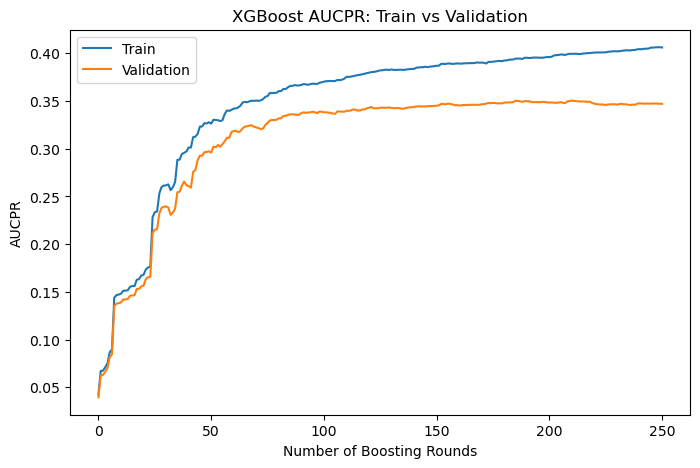

In [347]:
#check for overtraining with train vs val aucpr

eval_set = [(train_x, train_y), (val_x, val_y)]
bestmodel.fit(train_x, train_y,
    eval_set=eval_set,
    verbose=True
)

results = bestmodel.evals_result()
epochs = len(results['validation_0']['aucpr'])
x_axis = range(0, epochs)

plt.figure(figsize=(8,5))
plt.plot(x_axis, results['validation_0']['aucpr'], label='Train')
plt.plot(x_axis, results['validation_1']['aucpr'], label='Validation')
plt.legend()
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('AUCPR')
plt.title('XGBoost AUCPR: Train vs Validation')

plt.show()


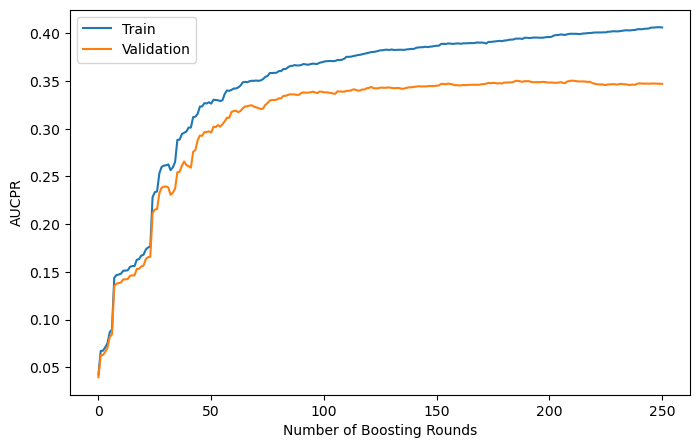

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, results['validation_0']['aucpr'], label='Train')
plt.plot(x_axis, results['validation_1']['aucpr'], label='Validation')
plt.legend()
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('AUCPR')


#plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\Plots2\auc_pr_curve.png",dpi=300, bbox_inches="tight")

plt.show()


In [365]:
# Threshold Moving based on max significance:

pred_val = bestmodel.predict_proba(val_x)[:,1]


cuts = np.linspace(0.01, 0.99, 200)
S_array = np.array([np.sum((val_y==1) & (pred_val>=c)) for c in cuts])
B_array = np.array([np.sum((val_y==0) & (pred_val>=c)) for c in cuts])

mask = (S_array + B_array) >= 100   # s+b



fom_array = np.divide(
    S_array,
    np.sqrt(S_array + B_array),
    out=np.zeros_like(S_array, dtype=float),
    where=(S_array + B_array) > 0
)


fom_array_masked = np.where(mask, fom_array, -np.inf)
best_cut = cuts[np.argmax(fom_array_masked)]


print("Best threshold for max significance:", best_cut)

# predict on x_test with cut based on significance: 
pred = bestmodel.predict_proba(x_test)[:, 1]
preds = (pred >= best_cut).astype(int)  # threshold adjusted to significance



Best threshold for max significance: 0.99


In [367]:
from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report)
# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = preds
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results


#y_proba = bestmodel.predict_proba(x_test)[:,1]
#threshold = 0.54  # experiment with 0.6, 0.65, 0.7
#y_pred_thresh = (y_proba >= threshold).astype(int)

evaluate_results(y_test, preds)

Confusion Matrix:
[[934630    804]
 [   688    466]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935434
         1.0       0.37      0.40      0.38      1154

    accuracy                           1.00    936588
   macro avg       0.68      0.70      0.69    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 38.45%
roc: 70.15%
recall: 40.38%
precision: 36.69%


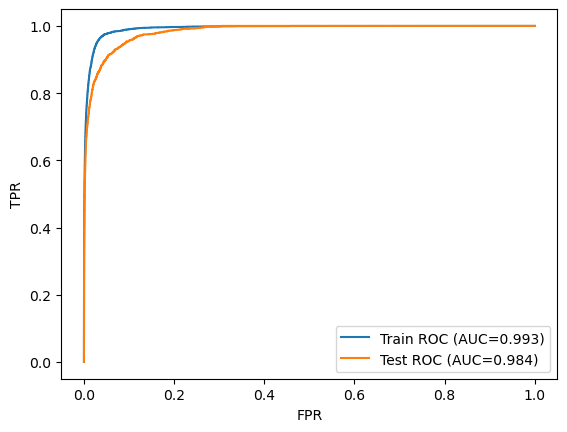

In [368]:
#checking for overfitting with roc

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_train_pred = bestmodel.predict_proba(x_train_full)[:,1]
y_test_pred  = bestmodel.predict_proba(x_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train_full, y_train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_pred)



auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)
#plt.xscale("log")
#plt.xlim(1e-4, 1)

plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_te:.3f})")
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()


Signal efficiency: 0.4038128249566724
Background rejection: 0.9991405059042113


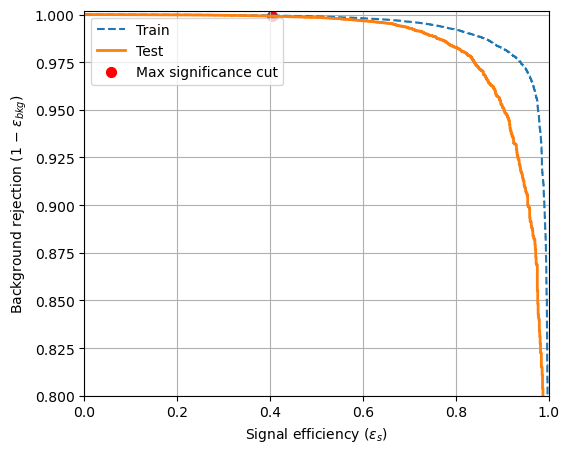

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Result on test data:

# fpr_tr, tpr_tr from ROC
# fpr_te, tpr_te

# pred_probs = model probabilities
tpr_at_cut = np.sum((preds >= best_cut) & (y_test==1)) / np.sum(y_test==1)
fpr_at_cut = np.sum((preds >= best_cut) & (y_test==0)) / np.sum(y_test==0)
bkg_rej_at_cut = 1 - fpr_at_cut

print("Signal efficiency:", tpr_at_cut)
print("Background rejection:", bkg_rej_at_cut)


fpr_te, tpr_te, thresholds_te = roc_curve(y_test, bestmodel.predict_proba(x_test)[:,1])

bkg_rej_tr = 1.0 - fpr_tr
bkg_rej_te = 1.0 - fpr_te


plt.figure(figsize=(6,5))
plt.plot(tpr_tr, bkg_rej_tr, label="Train", linestyle="--")
plt.plot( tpr_te, bkg_rej_te, label="Test", linewidth=2)
plt.scatter( tpr_at_cut, bkg_rej_at_cut, color='red', s=50, label='Max significance cut') #is the ideal cut max significance


plt.ylabel("Background rejection (1 − $ε_{bkg}$)") #Background rejection
plt.xlabel("Signal efficiency ($ε_{s}$)") #Signal efficiency
plt.ylim(0.8, 1.002)
plt.xlim(0.0, 1.001)
plt.legend()
plt.grid(True)

#plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\Plots2\eff_vs_reject.png",dpi=300, bbox_inches="tight")

plt.show()


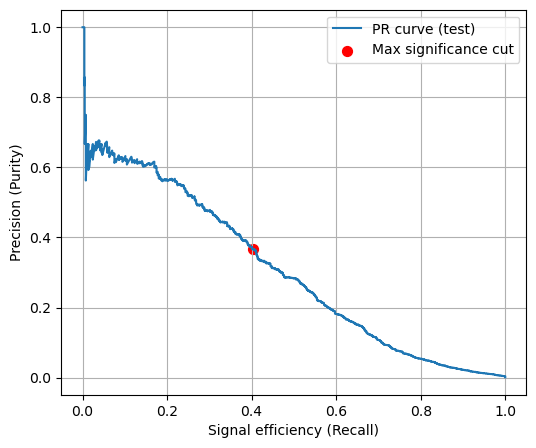

In [ ]:
from sklearn.metrics import precision_recall_curve



precision, recall, thresholds = precision_recall_curve(y_test, pred)

TP = np.sum((preds == 1) & (y_test == 1))
FP = np.sum((preds == 1) & (y_test == 0))
FN = np.sum((preds == 0) & (y_test == 1))

recall_at_cut = TP / (TP + FN)        # TPR
precision_at_cut = TP / (TP + FP)     # precision


plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="PR curve (test)")

plt.scatter(recall_at_cut, precision_at_cut, color='red', s=50, label="Max significance cut")

plt.xlabel("Signal efficiency (Recall)")
plt.ylabel("Precision (Purity)")
plt.legend()
plt.grid(True)
#plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\Plots2\pr_curve.png",dpi=300, bbox_inches="tight")

plt.show()


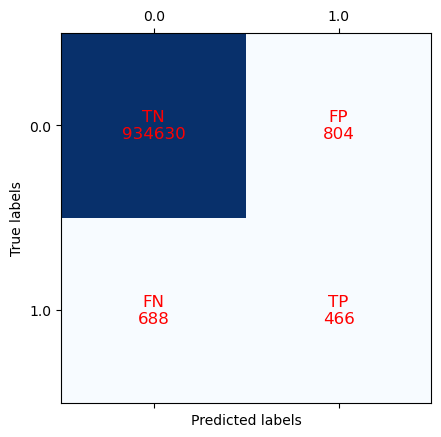

Signal efficiency/recall: 0.4038128249566724
Background rejection: 0.9991405059042113
Purity/precision: 0.3669291338582677


In [ ]:

#max significance cut applied:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, preds)

import numpy as np

labels = np.unique(y_test)

fig, ax = plt.subplots()
im = ax.matshow(cm, cmap=plt.cm.Blues)

# 


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Voeg extra label toe
        if i==0 and j==0:
            text = f"TN\n{cm[i,j]}"
        elif i==0 and j==1:
            text = f"FP\n{cm[i,j]}"
        elif i==1 and j==0:
            text = f"FN\n{cm[i,j]}"
        else:  # i==1 and j==1
            text = f"TP\n{cm[i,j]}"
        ax.text(j, i, text, ha="center", va="center", color="red", fontsize=12)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

#plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\Plots2\cm_xgb.png",dpi=300, bbox_inches="tight")

plt.show()

from sklearn.metrics import confusion_matrix



# purity, efficiency, background rejection
TP = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[0,0]

signal_eff = TP / (TP + FN)
bkg_rej = TN / (TN + FP)
purity = TP / (TP + FP)

print("Signal efficiency/recall:", signal_eff)
print("Background rejection:", bkg_rej)
print("Purity/precision:", purity)




In [372]:

y_score = bestmodel.predict_proba(x_test)[:, 1] # is without cut

signal_scores = y_score[y_test == 1]
background_scores = y_score[y_test == 0]


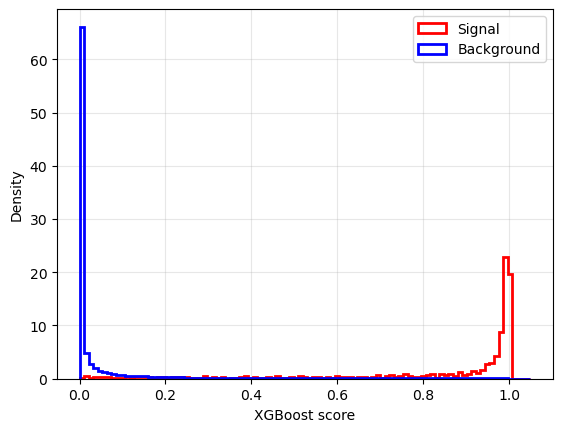

In [373]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1.05, 100)

plt.hist(signal_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='red', label='Signal')

plt.hist(background_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='blue', label='Background')

plt.xlabel("XGBoost score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [374]:


mask = y_score >= best_cut

mass_selected = m_test[mask]


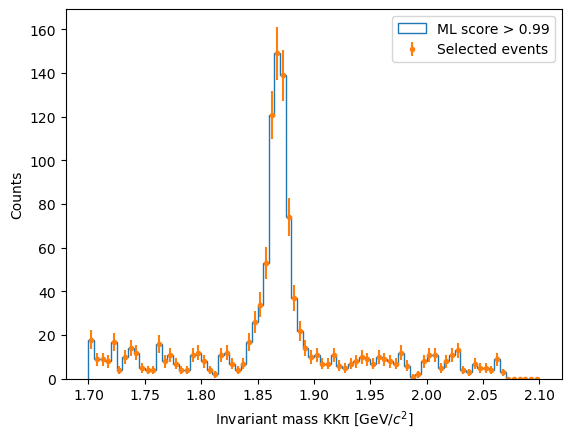

In [375]:
plt.hist(
    mass_selected,
    bins=80,
    range=(1.7, 2.1),
    histtype="step",
    label=f"ML score > {best_cut}"
)

range_mass = (1.7, 2.1)
hist_vals, bin_edges = np.histogram(mass_selected, bins=80, range=range_mass)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
errors = np.sqrt(hist_vals)  # Poisson errors

plt.errorbar(bin_centers, hist_vals, yerr=errors, fmt='.', label='Selected events')
plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.ylabel("Counts")
plt.legend()
plt.show()




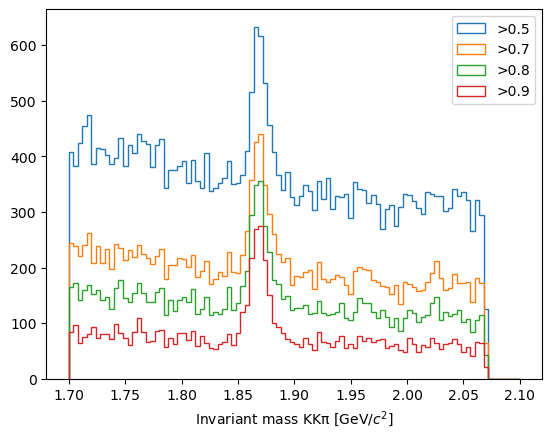

In [376]:
#check with different tresholds if peak is consistent

for cut in [0.5, 0.7, 0.8, 0.9]:
    mask = y_score > cut
    plt.hist(
        m_test[mask],
        bins=100,
        range=(1.7,2.1),
        histtype="step",
        label=f">{cut}"
    )

plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.legend()
plt.show()



In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt

def exponential(x, a, b, d):
    return a * np.exp(b * x) + d

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2/(2*sigma**2))

def signal_to_background_from_params(gauss_params, exp_params, k=3):
    a_g, mu_g, sigma_g = gauss_params
    a_e, b_e, d_e = exp_params

    x_min, x_max = mu_g - k*sigma_g, mu_g + k*sigma_g
    S, _ = quad(lambda x: gaussian(x, *gauss_params), x_min, x_max)
    B, _ = quad(lambda x: exponential(x, *exp_params), x_min, x_max)
    S_over_B = S / B
    return S, B, S_over_B





def bump_hunt(candidates, signal_window=(1.85, 1.89),savepath=None): #1.85, 1.9

    # Histogram

    #hist, bin_edges = np.histogram(candidates, bins, range=(np.min(candidates), np.max(candidates)))

    bin_width = 0.0094
    bin_width_counts = bin_width *1000 # for y-axis

    sigma_guess = 0.009# adjust to result
    sigma_g =  sigma_guess *1000
   
    x_min, x_max = min(candidates), max(candidates)
    N_bins = int(np.ceil((x_max - x_min) / bin_width))
    hist, bin_edges = np.histogram(candidates, bins=N_bins, range=(x_min, x_max))
    

    bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


    # Exclude signal window for background fit
    mask = (bin_centers < signal_window[0]) | (bin_centers > signal_window[1])
    hist_bkg, bins_bkg = hist[mask], bin_centers[mask]



    # Fit exponential
    popt_exp, pcov_exp = curve_fit(exponential, bins_bkg, hist_bkg, p0=(max(hist_bkg), -1, min(hist_bkg)),maxfev=35000)

    # Fit Gaussian + exponential

    def gauss_plus_exp(x, a_g, mu_g, sigma_g, a_e, b_e, d_e):
        return gaussian(x, a_g, mu_g, sigma_g) + exponential(x, a_e, b_e, d_e)

    p0 = (
        max(hist) - min(hist),  # a_g
        1.869,                  # mu
        sigma_guess,            # sigma
        *popt_exp               # a_e, b_e, d_e
    )

    popt, pcov = curve_fit(
        gauss_plus_exp,
        bin_centers,
        hist,
        p0=p0,
        maxfev=35000
    )

    # split parameters
    popt_gauss = popt[:3]
    popt_exp   = popt[3:]

    S, B, S_over_B = signal_to_background_from_params(popt_gauss, popt_exp)

    sigma_params = np.sqrt(np.diag(pcov))[:3]

    mu     = popt_gauss[1] * 1000
    sigma  = popt_gauss[2] * 1000
    dmu    = np.sqrt(pcov[1,1]) * 1000
    dsigma = np.sqrt(pcov[2,2]) * 1000


    
    # Plot
    x_fit = np.linspace(1.7, 2.1, 500)
    plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist), fmt='.', label='Data')
    plt.plot(x_fit, gauss_plus_exp(x_fit, *popt), label='Signal + background', color='green')

    plt.plot(x_fit, exponential(x_fit, *popt_exp), '--', label='Background', color='red')
   # plt.plot(x_fit, gaussian(x_fit, *popt_gauss), ':', label='Gaussian', color='blue')
    plt.text(1.91, max(hist)*0.54,
          f"μ = {mu:.3f} ± {dmu:.3f} MeV/c²\n"
          f"σ = {sigma:.3f} ± {dsigma:.3f} MeV/c²\n"
          f"S (3σ)= {S:.0f} ± {np.sqrt(S):.0f}\n",
         # f"S/B  = {S_over_B:.2f}",
       

          bbox=dict(facecolor='white', alpha=0.7))

    plt.xlabel('$M$(KKπ) (GeV/c²)')
    plt.ylabel(f"Counts per {bin_width_counts:.0f} MeV/c²\n")
    plt.legend()

   # if savepath is not None:
    #    plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()


    return popt_exp, popt_gauss, S, B, S_over_B





In [ ]:
print("Number of events in mass_selected:", len(mass_selected))
print("Min mass:", np.min(mass_selected))
print("Max mass:", np.max(mass_selected))
print("First 10 masses:", mass_selected[:10])


Number of events in mass_selected: 1270
Min mass: 1.6713147
Max mass: 2.0686634
First 10 masses: [2.010507  1.8513054 1.8581338 1.9072766 1.8819603 1.8719813 1.8780413
 1.8894352 1.9679664 1.8668362]


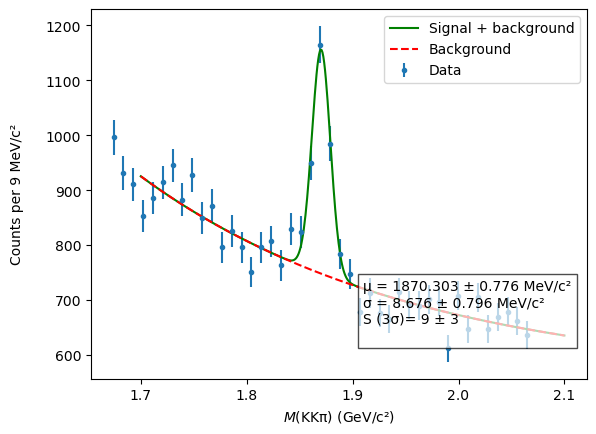

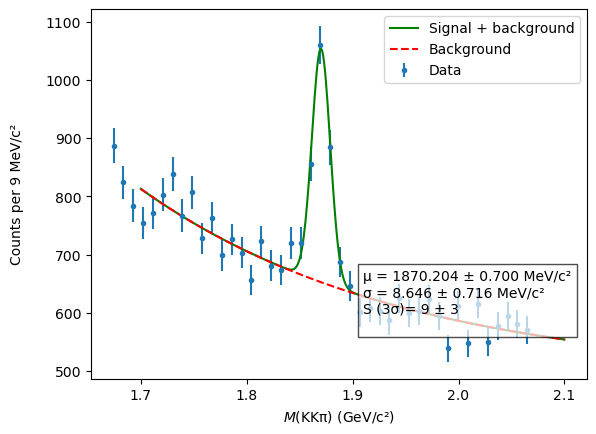

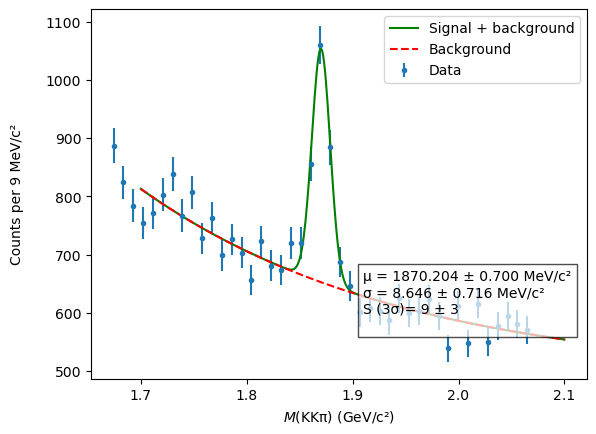

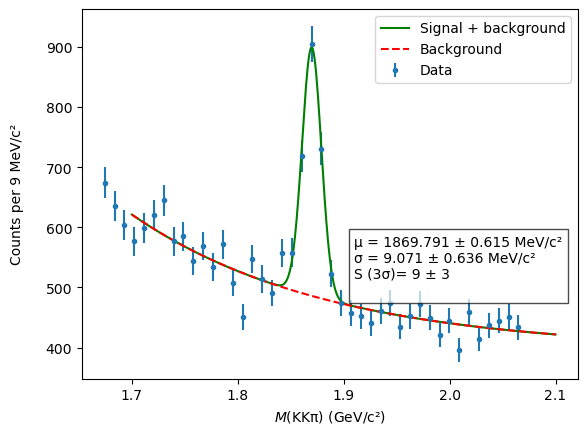

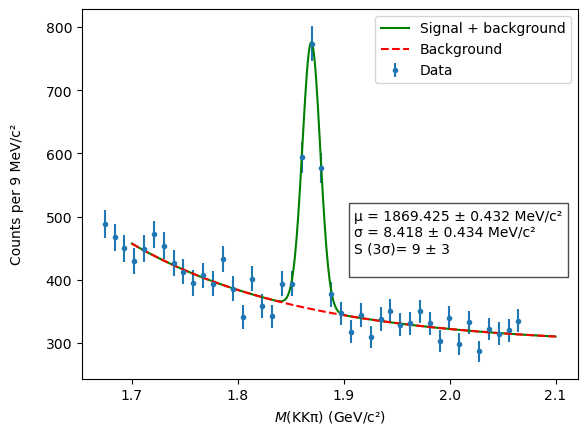

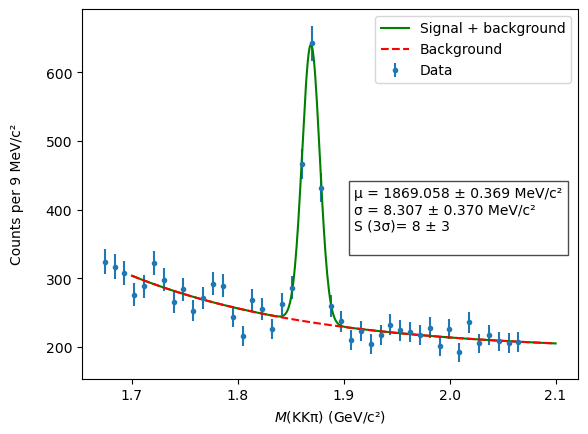

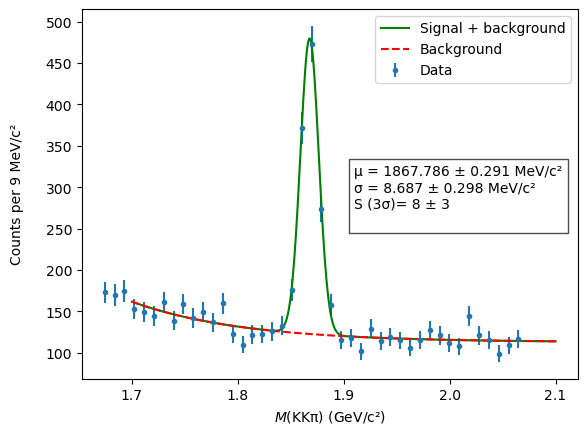

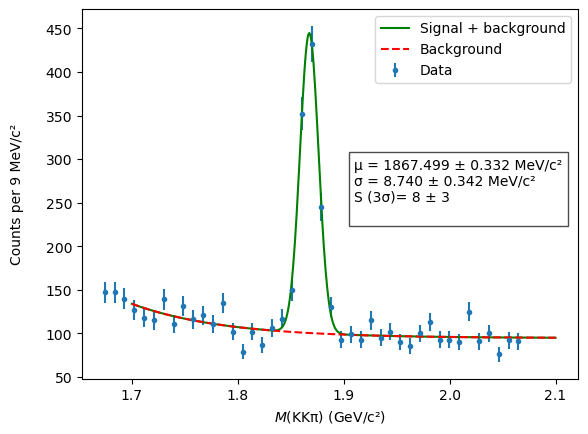

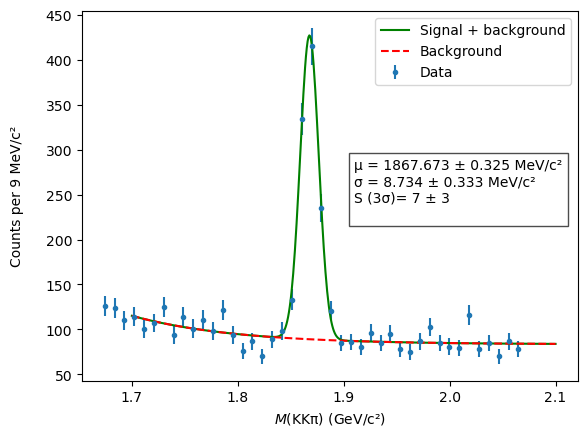

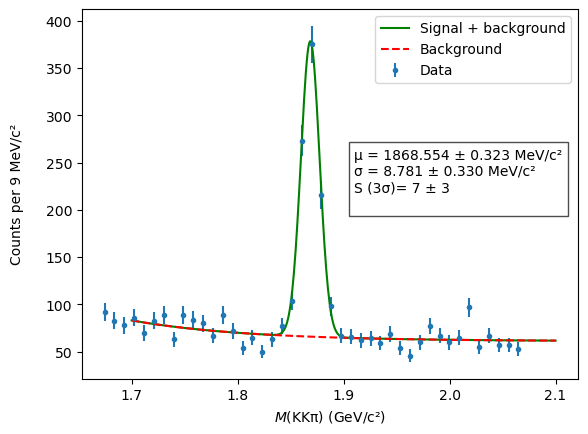

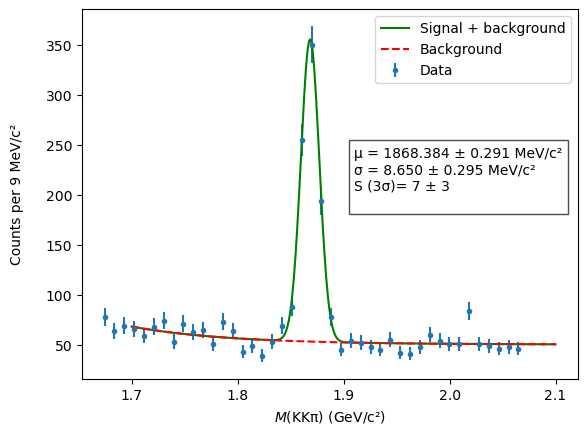

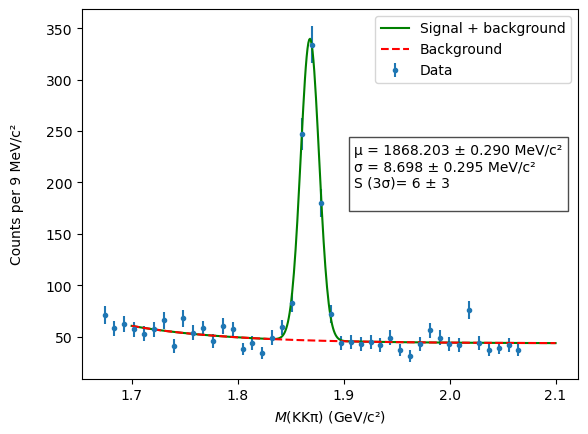

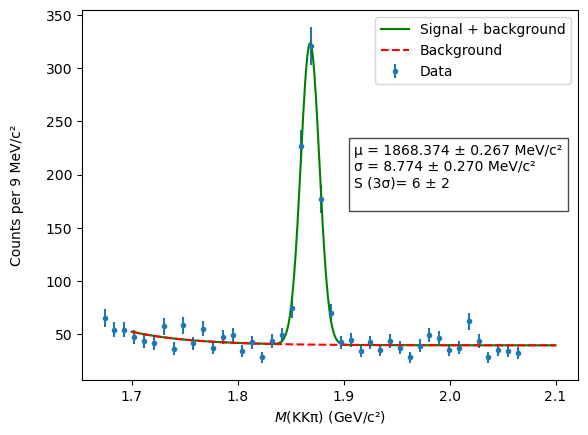

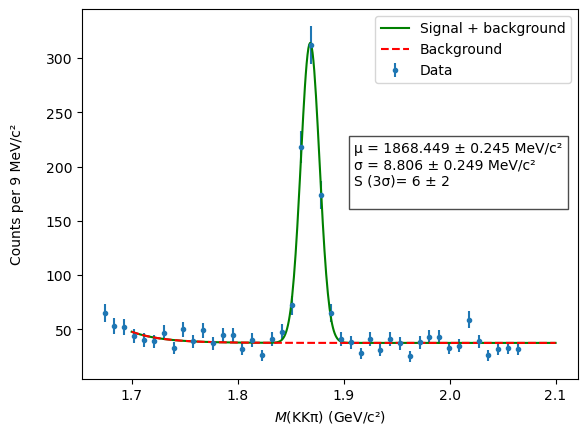

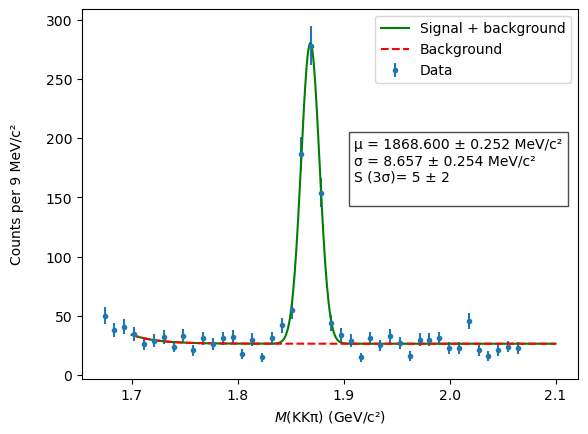

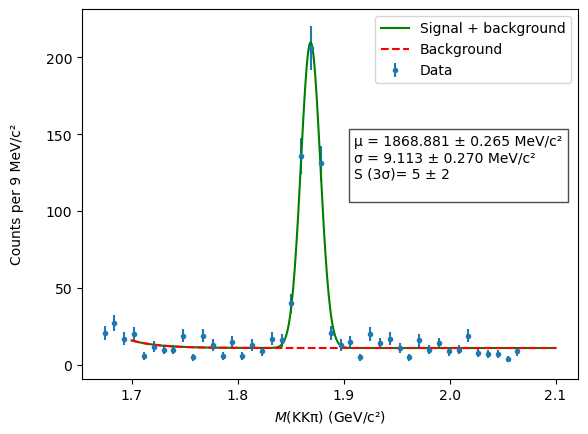

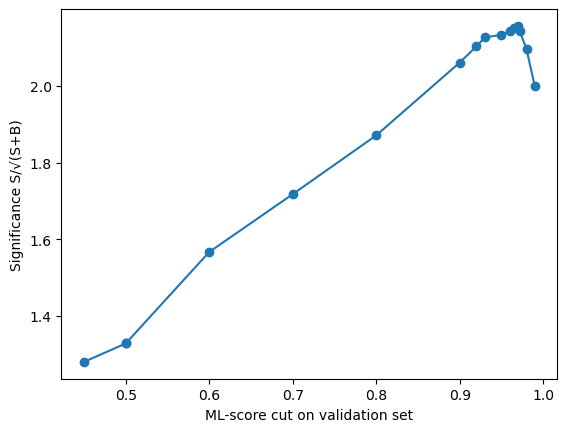

Best ML-score cut from validation set: 0.97


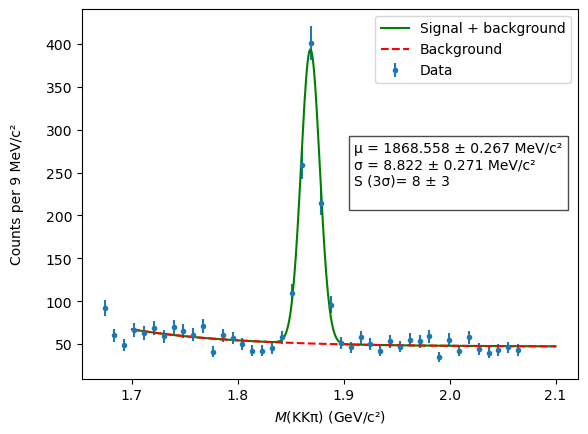

Test set significance: 2.3634793805788132
S/B: 2.8229839186393093


In [ ]:
#test cuts based on the validation set 

cuts = [0.45, 0.5, 0.5, 0.6, 0.7, 0.8,0.9, 0.92,0.93, 0.95,0.96,0.965,0.97,0.972, 0.98, 0.99]
significances = []


score_val   = bestmodel.predict_proba(val_x)[:, 1]


for cut in cuts:
    mask = score_val > cut
    mass_selected = m_val[mask]
    _, _, S, B, _ = bump_hunt(mass_selected)
    sig = S / np.sqrt(S+B)
    significances.append(sig)

plt.plot(cuts, significances, marker='o')
plt.xlabel("ML-score cut on validation set")
plt.ylabel("Significance S/√(S+B)")

plt.show()


# pick best cut
best_cut = cuts[np.argmax(significances)]
print("Best ML-score cut from validation set:", best_cut)

# apply cut to test set for final result:
score_test = bestmodel.predict_proba(x_test)[:, 1]
mask_test = score_test > best_cut
mass_selected_test = m_test[mask_test]

popt_exp, popt_gauss, S, B, S_over_B = bump_hunt(mass_selected_test, signal_window=(1.84, 1.89),savepath=r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\Plots2\2signal_xgb.png")
significance = S / np.sqrt(S + B)
print("Test set significance:", significance)
print("S/B:", S_over_B)


